In [1]:
#reference
#https://github.com/fnusatvik07/agent-builder-thinkinginglanggraph/blob/main/workbooks/08_parallelization.ipynb

**08.Parallelization**

Parallelization is a workflow pattern where multiple LLM calls execute simultaneously—either different subtasks for speed or the same task multiple times for validation and higher confidence.

When multiple parallel nodes write to the same state key, LangGraph raises an **InvalidUpdateError** unless a reducer is defined. A reducer tells LangGraph how to merge concurrent updates into a single state value.

**Flavour A:** different tasks, run together. A document review where one LLM checks grammar, another checks facts, a third checks tone. Each is doing a different job.

**Flavour B:** same task, run together for confidence. Three LLMs each propose a classification, you take a majority vote. Each is doing the same job on the same input.

Both look like the same graph: fan out from start, aggregate at the end.

In [ ]:
!pip install langchain langchain-groq langgraph python-dotenv ipython --quiet

In [3]:
import os
from dotenv import load_dotenv
load_dotenv('/content/.env.txt')
print("Keys loaded:", "GROQ_API_KEY")


Keys loaded: GROQ_API_KEY


In [4]:
import os, time
from pathlib import Path
from typing import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END

EASY:

In [5]:
from IPython.display import Image, display

def save_show_graph(app, name="Graph_parallelization"):
    png = app.get_graph().draw_mermaid_png()

    with open(f"{name}.png", "wb") as f:
        f.write(png)

    display(Image(png))

Production Style:

In [6]:
from pathlib import Path
from IPython.display import Image, display, Markdown

OUT = Path("graph_out")
OUT.mkdir(exist_ok=True)

def save_graph(app, name):
    graph = app.get_graph()

    (OUT / f"{name}.mmd").write_text(graph.draw_mermaid())

    try:
        (OUT / f"{name}.png").write_bytes(graph.draw_mermaid_png())
        print(f"Saved: {name}.png")
    except Exception:
        print("PNG generation failed")

def show_graph(name):
    png = OUT / f"{name}.png"

    if png.exists():
        display(Image(filename=png))
    else:
        display(Markdown(f"Open `graph_out/{name}.mmd` in mermaid.live"))

In [7]:
# Initialize Groq model
from langchain.chat_models import init_chat_model

In [8]:
llm = init_chat_model(
    "groq:llama-3.3-70b-versatile",
    temperature=0
)

print("LLM ready")

LLM ready


**2.Graph API: fan out and aggregate**

Three LLMs produce three different artefacts (joke, story, poem) about the same topic. An aggregator combines them.

Each LLM node writes to a different state key (joke, story, poem). They do not collide. If they did write to the same key you would need a reducer; we test that case after this demo.

Saved: 08_parallel.png


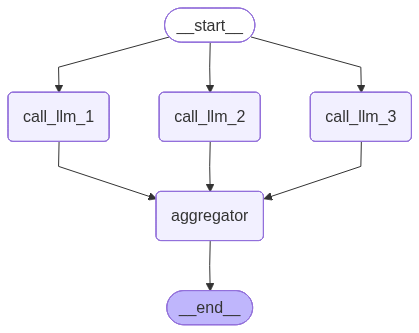

In [9]:
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

def call_llm_1(state: State):
    msg = llm.invoke(f"Write a one line joke about {state['topic']}")
    print("[joke ] done")
    return {"joke": msg.content}

def call_llm_2(state: State):
    msg = llm.invoke(f"Write a 2 sentence story about {state['topic']}")
    print("[story] done")
    return {"story": msg.content}

def call_llm_3(state: State):
    msg = llm.invoke(f"Write a 4 line poem about {state['topic']}")
    print("[poem ] done")
    return {"poem": msg.content}

def aggregator(state: State):
    combined = (
        f"=== {state['topic'].upper()} ===\n\n"
        f"STORY:\n{state['story']}\n\n"
        f"JOKE:\n{state['joke']}\n\n"
        f"POEM:\n{state['poem']}"
    )
    return {"combined_output": combined}

builder = StateGraph(State)
builder.add_node("call_llm_1", call_llm_1)
builder.add_node("call_llm_2", call_llm_2)
builder.add_node("call_llm_3", call_llm_3)
builder.add_node("aggregator", aggregator)

# Fan out: START goes to all three workers
builder.add_edge(START, "call_llm_1")
builder.add_edge(START, "call_llm_2")
builder.add_edge(START, "call_llm_3")
# Fan in: all three workers feed the aggregator
builder.add_edge("call_llm_1", "aggregator")
builder.add_edge("call_llm_2", "aggregator")
builder.add_edge("call_llm_3", "aggregator")
builder.add_edge("aggregator", END)

app = builder.compile()
save_graph(app, "08_parallel")
show_graph("08_parallel")



In [10]:
t0 = time.perf_counter()

state = app.invoke({"topic": "cats", "joke": "", "story": "", "poem": "", "combined_output": ""})

elapsed = time.perf_counter() - t0

print(f"\nelapsed: {elapsed:.2f}s\n")
print(state["combined_output"])

[joke ] done
[poem ] done
[story] done

elapsed: 0.40s

=== CATS ===

STORY:
As the sun set over the quiet neighborhood, a curious cat named Whiskers slipped out of the house and into the garden, where she chased after fireflies and danced under the starry sky. With a soft mew, Whiskers returned home, curling up on her owner's lap and purring contentedly as the warmth and comfort of the evening wrapped around her like a cozy blanket.

JOKE:
Why did the cat join a band, because it wanted to be the purr-cussionist.

POEM:
Whiskers twitch, eyes shine bright,
Fur as soft as the morning light.
With gentle purrs, they claim their space,
Furry friends with a gentle face.


In [11]:
#aggregator does not fire until all three parents have completed.
#Compare the elapsed time to roughly 3x a single call.

**3.Reducers: what they do and what breaks without them**

A reducer tells LangGraph how to combine multiple writes to the same state key in the same step.

**Without Reducer**

In [20]:
# ---- Scenario A: NO reducer ----
# Three voters fan out from START and each tries to write to state['votes'].
# LangGraph will refuse: only one writer per step is allowed by default.

class BadVoteState(TypedDict):
    votes: list[str]   # no reducer attached

def voter_1(state: BadVoteState):
    print('[voter-1] casting: positive')
    return {'votes': ['positive']}

def voter_2(state: BadVoteState):
    print('[voter-2] casting: positive')
    return {'votes': ['positive']}

def voter_3(state: BadVoteState):
    print('[voter-3] casting: negative')
    return {'votes': ['negative']}

bad = StateGraph(BadVoteState)
bad.add_node('voter_1', voter_1)
bad.add_node('voter_2', voter_2)
bad.add_node('voter_3', voter_3)

bad.add_edge(START, 'voter_1')
bad.add_edge(START, 'voter_2')
bad.add_edge(START, 'voter_3')

bad.add_edge('voter_1', END)
bad.add_edge('voter_2', END)
bad.add_edge('voter_3', END)

bad_app = bad.compile()

try:
    result = bad_app.invoke({'votes': []}) #app.invoke({...})
    votes = result['votes']
    print(f'final votes:   {votes}')
    print(f'total counted: {len(votes)} of 3')
except Exception as e:
    print('=== RUN FAILED ===')
    #first_line = str(e).split(chr(10))[0]
    print(f'{type(e).__name__}: {first_line}')
    #print()
    #print('Translation: three voters wrote to the same key in the same step, and')
    #print('LangGraph has no rule for how to combine those writes. So it refuses.')



[voter-1] casting: positive
[voter-2] casting: positive
[voter-3] casting: negative
=== RUN FAILED ===
InvalidUpdateError: At key 'votes': Can receive only one value per step. Use an Annotated key to handle multiple values.


**For real production systems, use logging instead of print**

In [ ]:
#logging no text file
import logging

logger = logging.getLogger(__name__)

try:
    result = bad_app.invoke({"votes": []})

except Exception as e:
    logger.exception("Graph execution failed")

In [25]:
import logging

logging.basicConfig(
    filename="error_log.txt",
    level=logging.ERROR,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True
)

try:
    result = bad_app.invoke({"votes": []})

except Exception:
    logging.exception("Graph execution failed")

[voter-1] casting: positive
[voter-2] casting: positive
[voter-3] casting: negative


**Same scenario, with Annotated[list, operator.add]**

In [27]:
# ---- Scenario B: WITH operator.add reducer ----
from collections import Counter

class GoodVoteState(TypedDict):
    votes: Annotated[list[str], operator.add]   # reducer attached

# Same voter functions, same wiring as before. Only the state class changed.
good = StateGraph(GoodVoteState)
good.add_node('voter_1', voter_1)
good.add_node('voter_2', voter_2)
good.add_node('voter_3', voter_3)
good.add_edge(START, 'voter_1')
good.add_edge(START, 'voter_2')
good.add_edge(START, 'voter_3')
good.add_edge('voter_1', END)
good.add_edge('voter_2', END)
good.add_edge('voter_3', END)
good_app = good.compile()

result = good_app.invoke({'votes': []})
votes = result['votes']
print()
print(f'final votes:   {votes}')
print(f'total counted: {len(votes)} of 3')

tally = Counter(votes)
print(f'tally:         {dict(tally)}')
print(f'winner:        {tally.most_common(1)[0][0]}')

winner, count = tally.most_common(1)[0]


[voter-1] casting: positive
[voter-2] casting: positive
[voter-3] casting: negative

final votes:   ['positive', 'positive', 'negative']
total counted: 3 of 3
tally:         {'positive': 2, 'negative': 1}
winner:        positive


**Bonus: a custom reducer**

Reducers are not limited to operator.add. Any function f(existing, incoming) -> merged works.

Here we keep only the most confident vote. The state holds a single (label, confidence) tuple, and the reducer compares confidences.

In [28]:
Vote = tuple[str, float]   # (label, confidence)

def keep_most_confident(existing, incoming):
    """Pick whichever vote has the higher confidence score."""
    if existing is None:
        return incoming
    if incoming is None:
        return existing
    return incoming if incoming[1] > existing[1] else existing

class ConfidentState(TypedDict):
    best_vote: Annotated[Vote | None, keep_most_confident]

def conf_voter_1(state): return {'best_vote': ('positive', 0.62)}
def conf_voter_2(state): return {'best_vote': ('positive', 0.91)}   # most confident
def conf_voter_3(state): return {'best_vote': ('negative', 0.71)}

g = StateGraph(ConfidentState)
g.add_node('v1', conf_voter_1)
g.add_node('v2', conf_voter_2)
g.add_node('v3', conf_voter_3)
g.add_edge(START, 'v1')
g.add_edge(START, 'v2')
g.add_edge(START, 'v3')
g.add_edge('v1', END)
g.add_edge('v2', END)
g.add_edge('v3', END)
app_c = g.compile()

result = app_c.invoke({'best_vote': None})
label, conf = result['best_vote']
print(f'kept the most confident vote: {label!r} at confidence {conf}')


kept the most confident vote: 'positive' at confidence 0.91


```text
Start timer
    ↓
Launch joke_task
Launch story_task
Launch poem_task
    ↓
Wait for results
    ↓
Print updates
    ↓
Stop timer
    ↓
Print total duration
```

In [15]:
from langgraph.func import entrypoint, task

@task
def joke_task(topic: str):
    return llm.invoke(f"Write a one line joke about {topic}").content

@task
def story_task(topic: str):
    return llm.invoke(f"Write a 2 sentence story about {topic}").content

@task
def poem_task(topic: str):
    return llm.invoke(f"Write a 4 line poem about {topic}").content

@entrypoint()
def parallel_workflow_func(topic: str):
    j = joke_task(topic)
    s = story_task(topic)
    p = poem_task(topic)
    # All three are now in flight. .result() joins them.
    return {
        "joke": j.result(),
        "story": s.result(),
        "poem": p.result(),
    }

t0 = time.perf_counter()
for chunk in parallel_workflow_func.stream("dogs", stream_mode="updates"):
    print(chunk)
print(f"elapsed: {time.perf_counter() - t0:.2f}s")


{'joke_task': 'Why did the dog go to the vet? Because he was feeling ruff.'}
{'poem_task': 'Tails that wag, hearts that gleam,\nFaithful friends, a loving dream.\nWith snouts so soft and eyes so bright,\nDogs bring joy to our lives, day and night.'}
{'story_task': 'As the sun set over the park, a group of playful dogs ran and chased each other, their tails wagging wildly as they enjoyed the warm evening air. Among them was a little terrier named Max, who stole the show with his adorable antics and earned endless belly rubs from his delighted owners.'}
{'parallel_workflow_func': {'joke': 'Why did the dog go to the vet? Because he was feeling ruff.', 'story': 'As the sun set over the park, a group of playful dogs ran and chased each other, their tails wagging wildly as they enjoyed the warm evening air. Among them was a little terrier named Max, who stole the show with his adorable antics and earned endless belly rubs from his delighted owners.', 'poem': 'Tails that wag, hearts that glea

1. Same Key + Parallel Writes = Need a Reducer   
Fix 1: Use different keys
Fix 2: Use a reducer

2. Aggregator Waits for All Parents.so failed nodes get another chance.

3. Too Much Parallelism Can Hit Rate Limits


Parallel writes → Need a reducer

Parallel joins  → Need all parents to succeed

Parallel LLMs   → Watch rate limits